In [1]:
import random
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import string
import seaborn as sns

In [2]:
print('matplotlib: {}'.format(matplotlib.__version__))

matplotlib: 3.8.4


In [3]:
size=["S","M","L","XL","XXL"]
color=["black","red","white","blue"]

In [4]:
def generate_random_id():
    return str(random.randrange(100,999))+random.choice(string.ascii_uppercase)
def generate_random_size():
    return random.choices(size,weights=[0.15,0.32,0.28,0.20,0.05])[0]
def generate_random_color():
    return random.choice(color)
def generate_random_price():
    return round(random.uniform(0,10000),2)
def generate_random_stock():
    return random.randrange(12,2345)

In [5]:
total_no_of_tshirts=1000
data=[]
for i in range(total_no_of_tshirts):
    row=[]
    row.append(generate_random_id())
    row.append(generate_random_size())
    row.append(generate_random_color())
    row.append(generate_random_price())
    row.append(generate_random_stock())
    data.append(row)
df=pd.DataFrame(data,columns=['id','size','color','price','stock'])
df

    

,id,size,color,price,stock
0,183K,XL,blue,7246.24,411
1,489D,M,blue,9198.97,1726
2,886U,XL,blue,3949.31,889
3,481V,L,red,2997.72,885
4,412P,S,blue,2424.00,1147
...,...,...,...,...,...
995,460W,XL,white,2655.23,1608
996,820Z,S,white,1194.00,1816
997,861X,XL,white,6632.18,18
998,793E,XL,white,6375.85,179


In [6]:
stock_by_size=df.groupby(['size']).sum()
stock_by_size

,id,color,price,stock
size,,,,
L,481V845P942I300P440O926L635Z915K207F222G488R23...,redredredblackblueredredblueblueblueredwhitebl...,1458770.36,338863
M,489D367N824P320J305L687F140X441K784A827X281H53...,bluewhiteblackblueblackwhiteblueblackblackredr...,1583973.14,362033
S,412P468R556X945W857H533K781J351T394X331H525B63...,blueblackblueblueblackblackblueblueblackredwhi...,699289.38,187297
XL,183K886U734P850Q803S770T719G943J162U163K149O63...,blueblueblueblueredwhiteblueblackwhiteredwhite...,857245.13,211140
XXL,785V762O295W341F868S446T916B611B399K317I592J37...,blackblackredbluewhiteredredredwhiteblueblackr...,188950.75,50587


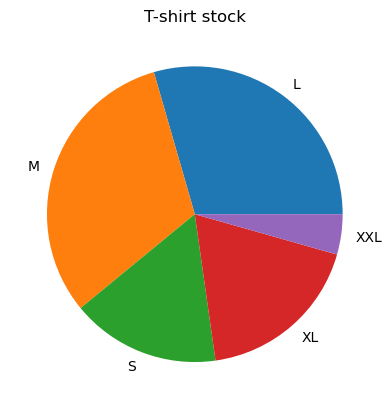

In [7]:
plt.pie(stock_by_size['stock'],labels=stock_by_size.index)
plt.title("T-shirt stock")
plt.show()

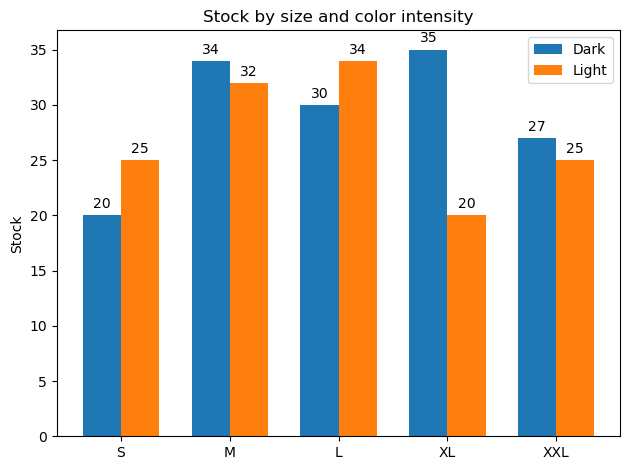

In [8]:
dark_stock=[20,34,30,35,27]
light_stock=[25,32,34,20,25]

x=np.arange(len(size)) #The label locations
width=0.35 #The width of the bars

fig,ax=plt.subplots()
rects1=ax.bar(x-width/2,dark_stock,width,label='Dark')
rects2=ax.bar(x+width/2,light_stock,width,label='Light')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Stock')
ax.set_title('Stock by size and color intensity')
ax.set_xticks(x)
ax.set_xticklabels(size)
ax.legend()

ax.bar_label(rects1,padding=3)
ax.bar_label(rects2,padding=3)
fig.tight_layout()
plt.show()


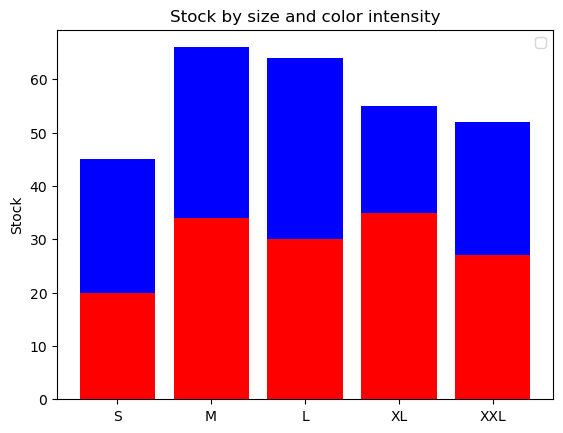

In [9]:
fig,ax=plt.subplots()
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Stock')
ax.set_title('Stock by size and color intensity')
ax.set_xticks(x)
ax.set_xticklabels(size)
ax.legend(["Dark","Light"])

# plot bars in stack manner
plt.bar(x, dark_stock, color='r')
plt.bar(x, light_stock, bottom=dark_stock, color='b')
plt.show()

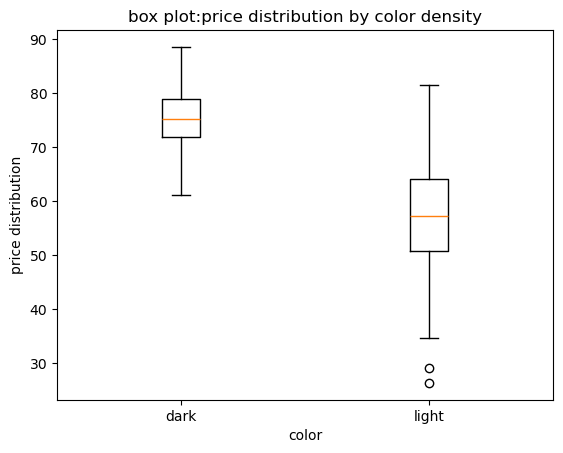

In [10]:
fig,ax=plt.subplots()
#price data
dark_price=np.random.normal(75,6,100)
light_price=np.random.normal(56,12,100)
data=list([dark_price,light_price])
#build a box plot
ax.boxplot(data)
#title and axis labels
ax.set_title('box plot:price distribution by color density')
ax.set_xlabel('color')
ax.set_ylabel('price distribution')
xticklabels=['dark','light']
ax.set_xticklabels(xticklabels)

#add horizontal grid lines
#ax.yaxis.grid(True)

#show the plot
plt.show()

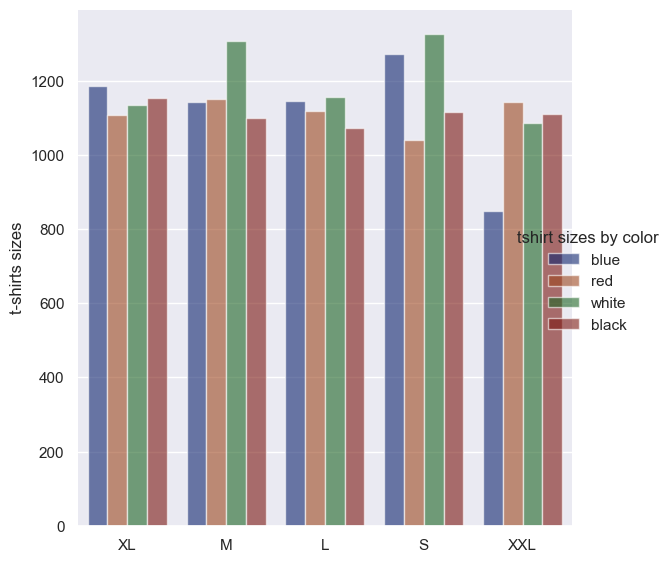

In [11]:
sns.set_theme(style="darkgrid")
g=sns.catplot(
    data=df,kind="bar",
    x="size",y="stock",hue="color",
    errorbar=None,palette="dark",alpha=.6,height=6
)
g.despine(left=True)
g.set_axis_labels("","t-shirts sizes")
g.legend.set_title("tshirt sizes by color")


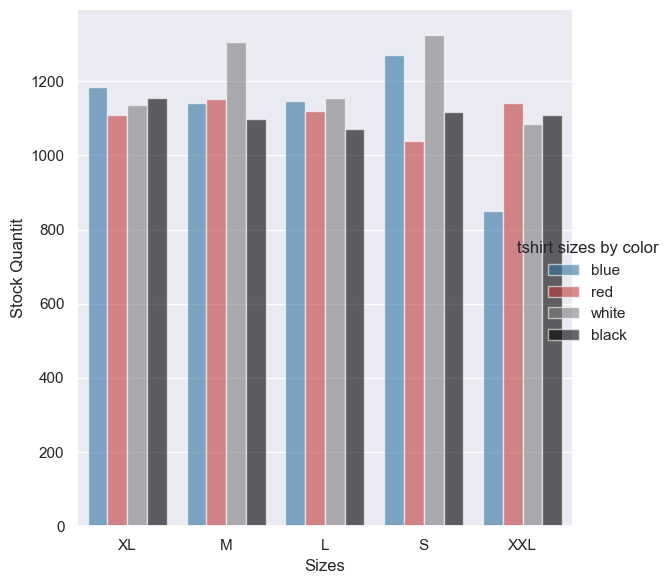

In [12]:
#color palette as dictionary
palette={"white":"tab:grey",
         "black":"black",
         "blue":"tab:blue",
         "red":"tab:red"}
g=sns.catplot(
    data=df,kind="bar",
    x="size",y="stock",hue="color",
    errorbar=None,palette=palette,alpha=.6,height=6
)
g.despine(left=True)
g.set_axis_labels("Sizes","Stock Quantit")
g._legend.set_title("tshirt sizes by color")

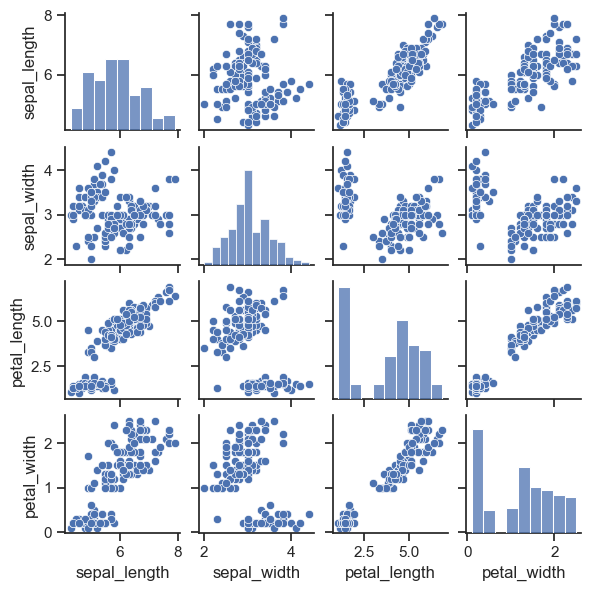

In [15]:
sns.set(style="ticks",color_codes=True)
iris=sns.load_dataset("iris")
g=sns.pairplot(iris,height=1.5,aspect=1)

plt.show()